In [4]:
import sys
sys.executable


'c:\\Users\\jp235\\construction_cost\\venv\\Scripts\\python.exe'

In [5]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


In [6]:
from pathlib import Path

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_DIR = DATA_DIR / "train"
EVAL_DIR = DATA_DIR / "eval"

PROJECT_ROOT, DATA_DIR


(WindowsPath('..'), WindowsPath('../data/raw'))

In [7]:
sorted([p.name for p in TRAIN_DIR.iterdir()])


['train_dataset_82ddf14911a54c729380209510ae25ac']

In [8]:
sorted([p.name for p in EVAL_DIR.iterdir()])


['evaluation_dataset_88c8c1d9376e4d9b8034f77ca19939b0']

In [9]:
TRAIN_DATASET_DIR = TRAIN_DIR / "train_dataset_82ddf14911a54c729380209510ae25ac"

sorted([p.name for p in TRAIN_DATASET_DIR.iterdir()])


['train_composite', 'train_tabular.csv']

In [10]:
train_df = pd.read_csv(TRAIN_DATASET_DIR / "train_tabular.csv")

train_df.shape


(1024, 23)

In [11]:
train_df.head(50)

,data_id,geolocation_name,quarter_label,country,year,deflated_gdp_usd,us_cpi,developed_country,landlocked,region_economic_classification,access_to_airport,access_to_port,access_to_highway,access_to_railway,straight_distance_to_capital_km,seismic_hazard_zone,flood_risk_class,tropical_cyclone_wind_risk,tornadoes_wind_risk,koppen_climate_zone,sentinel2_tiff_file_name,viirs_tiff_file_name,construction_cost_per_m2_usd
0,LP81L,Dinagat Islands,2019-Q3,Philippines,2019,2.996821e+11,117.689915,No,No,Lower-middle income,No,Yes,Yes,No,770.0,Moderate,Yes,High,Very Low,Af,sentinel_2_dinagat_islands_2019-Q3.tif,viirs_dinagat_islands_2019-Q3.tif,129.997420
1,E7EOB,29000 Nara,2024-Q2,Japan,2024,3.928801e+12,143.968241,Yes,Yes,High income,No,No,Yes,Yes,370.0,Moderate,Yes,Low,Very Low,Cfa,sentinel_2_29000_nara_2024-Q2.tif,viirs_29000_nara_2024-Q2.tif,1567.878774
2,WAOUA,05000 Akita,2020-Q1,Japan,2020,4.069008e+12,118.435291,Yes,No,High income,Yes,Yes,Yes,Yes,450.0,Moderate,Yes,Low,Very Low,Dfa,sentinel_2_05000_akita_2020-Q1.tif,viirs_05000_akita_2020-Q1.tif,2009.827701
3,2IZ5P,Cotabato,2020-Q4,Philippines,2020,2.912443e+11,119.402476,No,Yes,Lower-middle income,Yes,No,Yes,No,870.0,High,Yes,Moderate,Very Low,Af,sentinel_2_cotabato_2020-Q4.tif,viirs_cotabato_2020-Q4.tif,377.279961
4,RJ5XF,Pampanga,2019-Q3,Philippines,2019,2.996821e+11,117.689915,No,Yes,Lower-middle income,Yes,No,Yes,Yes,65.0,Moderate,Yes,Moderate,Very Low,Am,sentinel_2_pampanga_2019-Q3.tif,viirs_pampanga_2019-Q3.tif,163.905688
5,KM95D,Antique,2019-Q1,Philippines,2019,2.996821e+11,115.978119,No,No,Lower-middle income,Yes,Yes,Yes,No,410.0,Moderate,Yes,High,Very Low,Am,sentinel_2_antique_2019-Q1.tif,viirs_antique_2019-Q1.tif,236.315604
6,TT3IM,17000 Ishikawa,2021-Q2,Japan,2021,4.247589e+12,123.507547,Yes,No,High income,Yes,Yes,Yes,Yes,270.0,Moderate,Yes,Moderate,Low,Cfa,sentinel_2_17000_ishikawa_2021-Q2.tif,viirs_17000_ishikawa_2021-Q2.tif,1760.371729
7,39PEC,22000 Shizuoka,2021-Q3,Japan,2021,4.247589e+12,125.484873,Yes,No,High income,Yes,Yes,Yes,Yes,150.0,High,Yes,Moderate,Low,Cfa,sentinel_2_22000_shizuoka_2021-Q3.tif,viirs_22000_shizuoka_2021-Q3.tif,1998.151428
8,MAE38,21000 Gifu,2020-Q2,Japan,2020,4.069008e+12,117.795699,Yes,Yes,High income,No,No,Yes,Yes,270.0,Moderate,Yes,Low,Low,Cfa,sentinel_2_21000_gifu_2020-Q2.tif,viirs_21000_gifu_2020-Q2.tif,2038.472107
9,O1I3M,Catanduanes,2019-Q1,Philippines,2019,2.996821e+11,115.978119,No,No,Lower-middle income,Yes,Yes,Yes,No,370.0,Moderate,Yes,Very High,Very Low,Af,sentinel_2_catanduanes_2019-Q1.tif,viirs_catanduanes_2019-Q1.tif,173.967854


In [12]:
train_df["tropical_cyclone_wind_risk"].value_counts()



tropical_cyclone_wind_risk
Moderate     442
High         353
Low          204
Very High     21
Name: count, dtype: int64

In [13]:
train_df.isnull().sum()

data_id                            0
geolocation_name                   0
quarter_label                      0
country                            0
year                               0
deflated_gdp_usd                   0
us_cpi                             0
developed_country                  0
landlocked                         0
region_economic_classification     0
access_to_airport                  0
access_to_port                     0
access_to_highway                  0
access_to_railway                  0
straight_distance_to_capital_km    0
seismic_hazard_zone                0
flood_risk_class                   0
tropical_cyclone_wind_risk         4
tornadoes_wind_risk                0
koppen_climate_zone                0
sentinel2_tiff_file_name           0
viirs_tiff_file_name               0
construction_cost_per_m2_usd       0
dtype: int64

In [14]:
#Missing values (<0.5%) were imputed using the mode to avoid introducing noise or bias
mode_value = train_df["tropical_cyclone_wind_risk"].mode()[0]

train_df["tropical_cyclone_wind_risk"] = (
    train_df["tropical_cyclone_wind_risk"]
    .fillna(mode_value)
)


In [15]:
#Rare category "Very High" in tropical_cyclone_wind_risk was merged with "High" to reduce category sparsity and improve model robustness.

train_df["tropical_cyclone_wind_risk"] = (
    train_df["tropical_cyclone_wind_risk"]
    .replace({"Very High": "High"})
)


In [16]:
train_df.columns.to_list()


['data_id',
 'geolocation_name',
 'quarter_label',
 'country',
 'year',
 'deflated_gdp_usd',
 'us_cpi',
 'developed_country',
 'landlocked',
 'region_economic_classification',
 'access_to_airport',
 'access_to_port',
 'access_to_highway',
 'access_to_railway',
 'straight_distance_to_capital_km',
 'seismic_hazard_zone',
 'flood_risk_class',
 'tropical_cyclone_wind_risk',
 'tornadoes_wind_risk',
 'koppen_climate_zone',
 'sentinel2_tiff_file_name',
 'viirs_tiff_file_name',
 'construction_cost_per_m2_usd']

In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   data_id                          1024 non-null   object 
 1   geolocation_name                 1024 non-null   object 
 2   quarter_label                    1024 non-null   object 
 3   country                          1024 non-null   object 
 4   year                             1024 non-null   int64  
 5   deflated_gdp_usd                 1024 non-null   float64
 6   us_cpi                           1024 non-null   float64
 7   developed_country                1024 non-null   object 
 8   landlocked                       1024 non-null   object 
 9   region_economic_classification   1024 non-null   object 
 10  access_to_airport                1024 non-null   object 
 11  access_to_port                   1024 non-null   object 
 12  access_to_highway   

In [18]:
train_df.describe()


,year,deflated_gdp_usd,us_cpi,straight_distance_to_capital_km,construction_cost_per_m2_usd
count,1024.000000,1.024000e+03,1024.000000,1024.000000,1024.000000
mean,2020.796875,2.370260e+12,125.200014,468.287598,1109.311486
std,1.571916,1.854773e+12,9.335148,324.351177,837.074825
min,2019.000000,2.912443e+11,115.978119,0.000000,45.450769
25%,2020.000000,2.996821e+11,117.795699,250.000000,210.648077
50%,2021.000000,3.880440e+12,120.683801,400.000000,1521.307712
75%,2022.000000,4.069008e+12,130.298326,690.000000,1811.289875
max,2024.000000,4.247589e+12,144.727986,1550.000000,3628.201594


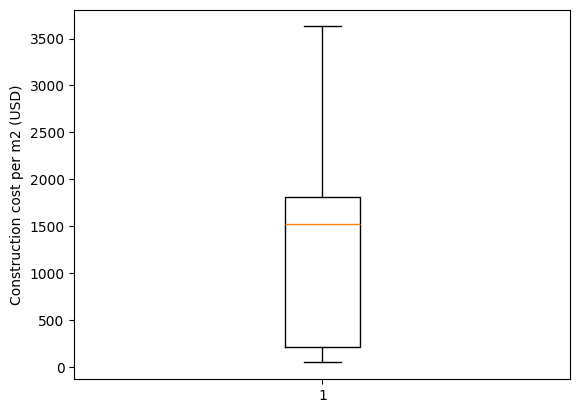

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(train_df['construction_cost_per_m2_usd'])
plt.ylabel("Construction cost per m2 (USD)")
plt.show()


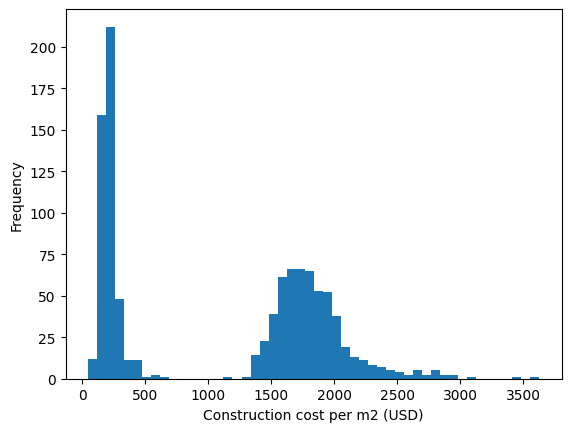

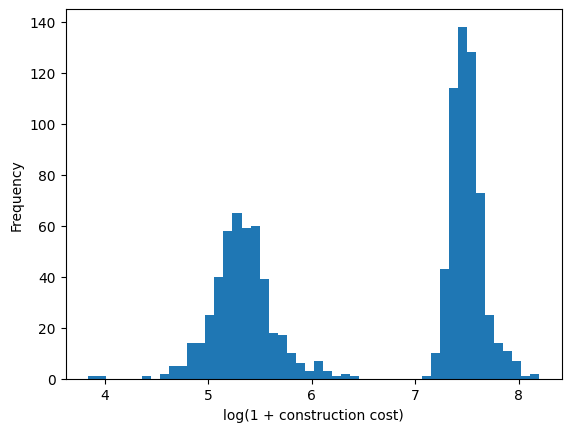

In [20]:
plt.figure()
plt.hist(train_df['construction_cost_per_m2_usd'], bins=50)
plt.xlabel("Construction cost per m2 (USD)")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(np.log1p(train_df['construction_cost_per_m2_usd']), bins=50)
plt.xlabel("log(1 + construction cost)")
plt.ylabel("Frequency")
plt.show()


In [21]:
target_col='construction_cost_per_m2_usd'
Q1 = train_df[target_col].quantile(0.25)
Q3 = train_df[target_col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = train_df[
    (train_df[target_col] < lower) |
    (train_df[target_col] > upper)
]

outliers.shape


(0, 23)

In [22]:
import numpy as np

y = np.log1p(train_df["construction_cost_per_m2_usd"])


In [23]:
columns_for_drop=[ 
    "construction_cost_per_m2_usd",
    "sentinel2_tiff_file_name",
    "viirs_tiff_file_name",
    "data_id",
    "geolocation_name"]

X=train_df.drop(columns=columns_for_drop)

In [24]:
numerical_cols=X.select_dtypes(include=['int64','float64']).columns.to_list()
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()



In [25]:
len(numerical_cols), len(categorical_cols)


(4, 14)

In [26]:
X.head(30)

,quarter_label,country,year,deflated_gdp_usd,us_cpi,developed_country,landlocked,region_economic_classification,access_to_airport,access_to_port,access_to_highway,access_to_railway,straight_distance_to_capital_km,seismic_hazard_zone,flood_risk_class,tropical_cyclone_wind_risk,tornadoes_wind_risk,koppen_climate_zone
0,2019-Q3,Philippines,2019,2.996821e+11,117.689915,No,No,Lower-middle income,No,Yes,Yes,No,770.0,Moderate,Yes,High,Very Low,Af
1,2024-Q2,Japan,2024,3.928801e+12,143.968241,Yes,Yes,High income,No,No,Yes,Yes,370.0,Moderate,Yes,Low,Very Low,Cfa
2,2020-Q1,Japan,2020,4.069008e+12,118.435291,Yes,No,High income,Yes,Yes,Yes,Yes,450.0,Moderate,Yes,Low,Very Low,Dfa
3,2020-Q4,Philippines,2020,2.912443e+11,119.402476,No,Yes,Lower-middle income,Yes,No,Yes,No,870.0,High,Yes,Moderate,Very Low,Af
4,2019-Q3,Philippines,2019,2.996821e+11,117.689915,No,Yes,Lower-middle income,Yes,No,Yes,Yes,65.0,Moderate,Yes,Moderate,Very Low,Am
5,2019-Q1,Philippines,2019,2.996821e+11,115.978119,No,No,Lower-middle income,Yes,Yes,Yes,No,410.0,Moderate,Yes,High,Very Low,Am
6,2021-Q2,Japan,2021,4.247589e+12,123.507547,Yes,No,High income,Yes,Yes,Yes,Yes,270.0,Moderate,Yes,Moderate,Low,Cfa
7,2021-Q3,Japan,2021,4.247589e+12,125.484873,Yes,No,High income,Yes,Yes,Yes,Yes,150.0,High,Yes,Moderate,Low,Cfa
8,2020-Q2,Japan,2020,4.069008e+12,117.795699,Yes,Yes,High income,No,No,Yes,Yes,270.0,Moderate,Yes,Low,Low,Cfa
9,2019-Q1,Philippines,2019,2.996821e+11,115.978119,No,No,Lower-middle income,Yes,Yes,Yes,No,370.0,Moderate,Yes,High,Very Low,Af


In [27]:
categorical_cols

['quarter_label',
 'country',
 'developed_country',
 'landlocked',
 'region_economic_classification',
 'access_to_airport',
 'access_to_port',
 'access_to_highway',
 'access_to_railway',
 'seismic_hazard_zone',
 'flood_risk_class',
 'tropical_cyclone_wind_risk',
 'tornadoes_wind_risk',
 'koppen_climate_zone']

In [28]:
train_df.groupby("country")["construction_cost_per_m2_usd"].describe()


,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Japan,567.0,1830.268632,309.108275,1191.698232,1630.923139,1776.895274,1957.640801,3628.201594
Philippines,457.0,214.819797,71.979599,45.450769,173.541215,203.223806,237.760641,619.088659


In [29]:
train_df.corr(numeric_only=True)["construction_cost_per_m2_usd"].sort_values()


straight_distance_to_capital_km   -0.052905
year                               0.385670
us_cpi                             0.415280
deflated_gdp_usd                   0.961621
construction_cost_per_m2_usd       1.000000
Name: construction_cost_per_m2_usd, dtype: float64